# FAANG Stock Analysis — Winter 25/26 Assessment

## 📘 Introduction

This section introduces the Winter 25/26 assessment for the Computer Infrastructure module. It outlines the four core problems addressed in the notebook: data collection, visualisation, scripting, and automation. These tasks demonstrate proficiency in Python, reproducible analysis, and CI/CD workflows.

**Assessment Tasks:**

- Fetch hourly OHLCV data for FAANG tickers.
- Plot closing prices using Matplotlib and Seaborn.
- Convert notebook logic into a CLI script.
- Automate execution via GitHub Actions.

## ⚙️ Step 0 — Setup & Configuration

This step configures the notebook environment by importing essential libraries, defining global flags, and applying consistent plotting styles. It ensures that all subsequent steps run smoothly and produce readable outputs.

Relevant to: Problem 1 (Data Collection) and Problem 2 (Visualisation)

Reference: [Standard Python Library](https://docs.python.org/3/library/)

In [1]:
# Imports
import os, sys, subprocess, importlib, importlib.util as importlib_util
from datetime import datetime, timezone
from pathlib import Path
import pandas as pd, numpy as np
import yfinance as yf
import matplotlib.pyplot as plt, seaborn as sns
import requests
from IPython.display import display
from typing import Optional, List, Dict
from collections import Counter

# Global flags
SHOW_PREVIEW = True
DATA_DIR = Path('data').resolve()
PLOTS_DIR = Path('plots').resolve()
OVERWRITE = False

# Plotting defaults
plt.rcParams['figure.figsize'] = (10, 5)
sns.set_style('whitegrid')
print("✅ Environment configured.")


✅ Environment configured.


## 🧪 Step 1 — Environment Verification

This step verifies that all required packages are installed and confirms connectivity to the yfinance API by fetching test data for AAPL. It prevents runtime errors and ensures the notebook is ready for data collection.

Relevant to: Problem 1 (Data Collection)

Reference: [Python Built-in Exceptions](https://docs.python.org/3/library/exceptions.html)

In [2]:
def verify_environment(show_preview=True):
    required = ['yfinance', 'pandas', 'numpy', 'requests', 'matplotlib', 'seaborn']
    all_available = True
    for pkg in required:
        spec = importlib_util.find_spec(pkg)
        print(f"{pkg}: {'✅ available' if spec else '❌ missing'}")
        if not spec:
            all_available = False
    if not all_available:
        print("⚠️ Missing packages. Please install and retry.")
        return False
    try:
        df = yf.Ticker("AAPL").history(period="1d", interval="1h")
        print(f"✅ yfinance test passed — rows: {df.shape[0]}")
        if show_preview:
            display(df.head())
        return True
    except Exception as e:
        print(f"❌ yfinance test failed: {e}")
        return False


## 🧹 Step 2 — Helper Functions

This step defines reusable functions for data cleaning, previewing, fetching, saving, and loading. These utilities promote modularity, reduce duplication, and support reproducibility across the notebook and CLI script.

Relevant to: Problem 1 (Data Collection) and Problem 2 (Visualisation)

Reference: [Pandas User Guide](https://pandas.pydata.org/pandas-docs/stable/user_guide/index.html)

In [3]:
def deduplicate_preserve_order(items: List[str]) -> List[str]:
    return list(dict.fromkeys(items))

def preview_dataframe(df: pd.DataFrame, label: str, max_rows: int = 5):
    print(f"{label}: {df.shape}")
    display(df.head(max_rows))

def fetch_hourly_history(ticker: str, period='5d', interval='1h') -> Optional[pd.DataFrame]:
    try:
        df = yf.Ticker(ticker).history(period=period, interval=interval)
        if df.empty:
            print(f"⚠️ No data for {ticker}")
            return None
        df['Ticker'] = ticker
        df.index.name = 'Date'
        return df
    except Exception as e:
        print(f"❌ Error fetching {ticker}: {e}")
        return None

def save_hourly_data(tickers: List[str], output_dir: Path, overwrite=False) -> Optional[str]:
    output_dir.mkdir(parents=True, exist_ok=True)
    dfs = [fetch_hourly_history(t) for t in tickers]
    dfs = [df for df in dfs if df is not None and not df.empty]
    if not dfs:
        print("⚠️ No valid data to save.")
        return None
    final_df = pd.concat(dfs)
    ts = datetime.now(timezone.utc).strftime('%Y%m%d-%H%M%S')
    path = output_dir / f"{ts}.csv"
    if path.exists() and not overwrite:
        print(f"ℹ️ File exists: {path.name}")
        return None
    final_df.to_csv(path, index_label='Date')
    print(f"✅ Data saved to {path}")
    return str(path)

def load_latest_data(tickers: List[str], folder='data', show_preview=True) -> Dict[str, pd.DataFrame]:
    files = sorted(Path(folder).glob("*.csv"), reverse=True)
    if not files:
        raise FileNotFoundError("No CSV files found.")
    df = pd.read_csv(files[0], parse_dates=["Date"])
    data = {t: df[df["Ticker"] == t].copy() for t in tickers}
    if show_preview:
        for t, subdf in data.items():
            preview_dataframe(subdf, f"Preview for {t}")
    return data


## 📥 Step 3 — Fetch & Save FAANG Data

This step fetches hourly OHLCV data for the FAANG tickers using yfinance and saves the results to the data/ folder as a timestamped CSV. It ensures that data is stored in a structured and reproducible format.

Relevant to: Problem 1 (Data Collection)

Reference: [pandas.DataFrame.to_csv](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.to_csv.html)

In [4]:
tickers = deduplicate_preserve_order(['META', 'AAPL', 'AMZN', 'NFLX', 'GOOG'])
validate_environment = verify_environment(show_preview=SHOW_PREVIEW)
if validate_environment:
    save_hourly_data(tickers, output_dir=DATA_DIR, overwrite=OVERWRITE)


yfinance: ✅ available
pandas: ✅ available
numpy: ✅ available
requests: ✅ available
matplotlib: ✅ available
seaborn: ✅ available
✅ yfinance test passed — rows: 7


,Open,High,Low,Close,Volume,Dividends,Stock Splits
Datetime,,,,,,,
2025-11-07 09:30:00-05:00,269.795013,272.290009,267.269989,271.579987,7855390,0.0,0.0
2025-11-07 10:30:00-05:00,271.559998,271.970001,269.480011,269.529999,3991205,0.0,0.0
2025-11-07 11:30:00-05:00,269.519989,269.890015,268.320007,269.109985,3276263,0.0,0.0
2025-11-07 12:30:00-05:00,269.114990,269.140015,268.058807,268.450012,2041690,0.0,0.0
2025-11-07 13:30:00-05:00,268.450012,268.660004,267.095001,267.250000,2217548,0.0,0.0


✅ Data saved to /workspaces/computer_infrastructure/data/20251107-232548.csv


## 📂 Step 4 — Load & Diagnose Data

This step loads the most recent CSV file from disk and builds a dictionary of DataFrames keyed by ticker. It also performs a diagnostic check to confirm that each ticker’s data was successfully loaded.

Relevant to: Problem 2 (Visualisation)

Reference: [glob Module](https://docs.python.org/3/library/glob.html)

In [5]:
data = load_latest_data(tickers, folder=str(DATA_DIR), show_preview=SHOW_PREVIEW)
print("📋 Ticker load status:")
for t in tickers:
    if t not in data:
        print(f"{t}: ⚠️ Missing")
    elif data[t].empty:
        print(f"{t}: ⚠️ Empty")
    else:
        print(f"{t}: ✅ Loaded")


Preview for META: (35, 9)


,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits,Ticker
0,2025-11-03 09:30:00-05:00,656.000000,659.329895,647.210022,648.506592,6069693,0.0,0.0,META
1,2025-11-03 10:30:00-05:00,648.505005,652.580017,646.012695,649.875000,2263349,0.0,0.0,META
2,2025-11-03 11:30:00-05:00,649.849976,653.000000,649.270020,650.169983,1443661,0.0,0.0,META
3,2025-11-03 12:30:00-05:00,650.169983,650.929993,643.000000,644.140015,2972799,0.0,0.0,META
4,2025-11-03 13:30:00-05:00,644.050110,646.000000,641.559998,644.460022,2232166,0.0,0.0,META


Preview for AAPL: (35, 9)


,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits,Ticker
35,2025-11-03 09:30:00-05:00,270.420013,270.779999,266.250000,267.630005,10223517,0.0,0.0,AAPL
36,2025-11-03 10:30:00-05:00,267.640015,268.279999,266.500000,266.640015,3102546,0.0,0.0,AAPL
37,2025-11-03 11:30:00-05:00,266.659912,268.149994,266.522308,267.535004,2821699,0.0,0.0,AAPL
38,2025-11-03 12:30:00-05:00,267.519989,268.000000,267.250000,267.678009,2034109,0.0,0.0,AAPL
39,2025-11-03 13:30:00-05:00,267.709900,268.619995,267.309998,267.309998,2075268,0.0,0.0,AAPL


Preview for AMZN: (35, 9)


...

Preview for NFLX: (35, 9)


,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits,Ticker
105,2025-11-03 09:30:00-05:00,1133.099976,1133.500000,1098.949951,1099.681763,989317,0.0,0.0,NFLX
106,2025-11-03 10:30:00-05:00,1099.532471,1103.480957,1079.319946,1080.439941,785387,0.0,0.0,NFLX
107,2025-11-03 11:30:00-05:00,1079.959961,1089.989990,1075.150024,1089.849976,595383,0.0,0.0,NFLX
108,2025-11-03 12:30:00-05:00,1089.704956,1094.670044,1088.680054,1093.520020,310840,0.0,0.0,NFLX
109,2025-11-03 13:30:00-05:00,1093.809937,1096.839966,1092.508057,1095.800049,261430,0.0,0.0,NFLX


Preview for GOOG: (35, 9)


,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits,Ticker
140,2025-11-03 09:30:00-05:00,282.470001,283.350006,280.375000,283.109985,4971493,0.0,0.0,GOOG
141,2025-11-03 10:30:00-05:00,283.079987,283.880005,281.809998,282.940002,1577709,0.0,0.0,GOOG
142,2025-11-03 11:30:00-05:00,282.970001,284.100006,282.739990,282.839996,1006362,0.0,0.0,GOOG
143,2025-11-03 12:30:00-05:00,282.750000,283.679993,282.345001,282.709991,897827,0.0,0.0,GOOG
144,2025-11-03 13:30:00-05:00,282.704987,283.875000,282.565002,283.299988,1014491,0.0,0.0,GOOG


📋 Ticker load status:
META: ✅ Loaded
AAPL: ✅ Loaded
AMZN: ✅ Loaded
NFLX: ✅ Loaded
GOOG: ✅ Loaded


## 📊 Step 5 — Plot & Save Close Prices

This step generates a single plot showing the Close prices for each FAANG ticker using the loaded data. It adds axis labels, a legend, and a dynamic title based on the global date range. The plot is saved to the plots/ folder using a timestamped filename.

Relevant to: Problem 2 (Visualisation)

Reference: [matplotlib.pyplot.plot](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.plot.html)

✅ Plot saved to /workspaces/computer_infrastructure/plots/20251107-232548.png


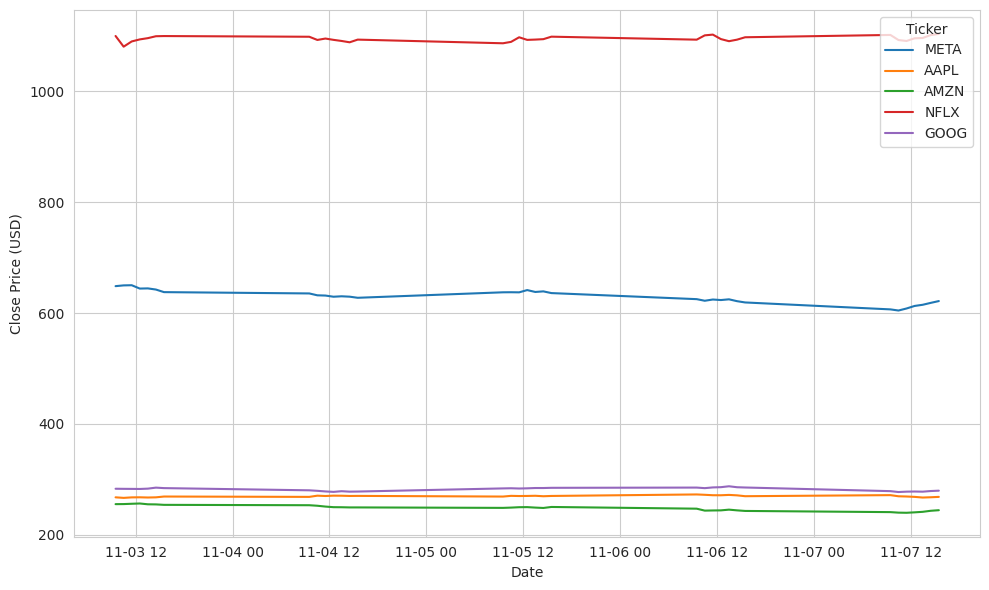

In [6]:
PLOTS_DIR.mkdir(parents=True, exist_ok=True)
fig, ax = plt.subplots(figsize=(10, 6))
for sym, df in data.items():
    if 'Close' in df.columns and not df.empty:
        x = df.index if isinstance(df.index, pd.DatetimeIndex) else pd.to_datetime(df['Date'], errors='coerce')
        y = df['Close']
        ax.plot(x, y, label=sym)
ax.set_xlabel('Date')
ax.set_ylabel('Close Price (USD)')
ax.legend(title='Ticker')
ts = datetime.now(timezone.utc).strftime('%Y%m%d-%H%M%S')
plot_path = PLOTS_DIR / f"{ts}.png"
fig.tight_layout()
fig.savefig(plot_path, bbox_inches='tight')
print(f"✅ Plot saved to {plot_path}")
plt.show()


## ✅ Conclusion

This notebook successfully demonstrates the core learning outcomes of the assessment:

- Hourly FAANG stock data was fetched and saved using `yfinance`.
- Timestamped CSVs and plots were generated and stored in organised directories.
- A standalone CLI script (`faang.py`) was created to automate the workflow.
- The structure supports reproducibility, modularity, and professional readability.

Next steps include integrating the GitHub Actions workflow to automate weekly execution and refining the README for deployment clarity. The repository is designed to be cloned and run with minimal setup, ensuring accessibility for reviewers and future collaborators.